# Data Mining & Informatics
## Mary-Jane Masagbor
### 

# 7CS033 Assignment Task 1

### Complete the following tasks.

#### You should comment on your code where appropriate. Failing to add comments may result in a mark deduction.

#### You should write any explainations in the report cell if the task explicitly asks for this or if you wish to expand upon your solution.

#### Ensure you have ran your code cell and printed any of the required outputs. If necessary you can use more than one code cell.

### TASK 1.1: Write a code to receive an optional text, capitalise all words in the text and print them (2%)

In [6]:
# TASK 1.1

import pandas as pd
import numpy as np

text = input("welcome to task 1").strip()

if text == "":
    print("Capitalised text: (no text entered)")
else:
    capitalised_text = text.title()
    print("Capitalised text:", capitalised_text)


welcome to task 1 welcome to task 1


Capitalised text: Welcome To Task 1


**Explanation (Task 1.1)**  
The program reads a text string and using Python’s built in `.title()` function, it converts the first character of each word to uppercase. Finally, it prints the capitalised text.


### TASK 1.2: Write a program that prompts the user to input the radius of a circle and calculates its area (2%)

In [11]:
import math

radius = float(input("Enter the radius of the circle: "))

area = math.pi * (radius ** 2)

print("The area of the circle is:", area)

Enter the radius of the circle:  3


The area of the circle is: 28.274333882308138


**Explanation (Task 1.2)**  
The program here requests to input the radius. It then uses the formula (πr²) from the math library to calculate and print the area.




### TASK 1.3: Download and import the 'adult' dataset from Canvas. Write a function to split the dataset column-wise into two halves and swap the first half with the second half (3%)

In [12]:
df = pd.read_csv("adult (1).csv")

def swap_columns(dataframe):
    """
    Splits the dataframe into two halves by columns and swaps them.
    Returns a new dataframe with the swapped column order.
    """
    mid = len(dataframe.columns) // 2

    first_half = dataframe.iloc[:, :mid]
    second_half = dataframe.iloc[:, mid:]

    swapped_df = pd.concat([second_half, first_half], axis=1)

    return swapped_df

swapped_dataset = swap_columns(df)

print("Original columns (first 8):", df.columns[:8].tolist())
print("Swapped columns (first 8):", swapped_dataset.columns[:8].tolist())
swapped_dataset.head()




Original columns (first 8): ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship']
Swapped columns (first 8): ['relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age,workclass,fnlwgt,education,education-num,marital-status,occupation
0,Not-in-family,White,Male,2174,0,40,United-States,<=50K,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical
1,Husband,White,Male,0,0,13,United-States,<=50K,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial
2,Not-in-family,White,Male,0,0,40,United-States,<=50K,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners
3,Husband,Black,Male,0,0,40,United-States,<=50K,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners
4,Wife,Black,Female,0,0,40,Cuba,<=50K,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty


**Explanation (Task 1.3)**   
The dataset is loaded with pandas. The function finds the midpoint of the columns, slices the dataframe into two halves, then swaps them using `pd.concat()`.

### Task 1.4: Write a function that takes the names of two numerical columns as input and compares their values for all rows. If the value in the first column is greater than the value in the second column, the function should return True; otherwise, it should return False. The function should append a new column to the dataset to store the comparison results for all rows. Apply the function to the 'age' and 'hours-per-week' columns in the adult dataset and print the resulting dataset (3%)

In [15]:
def compare_columns(dataframe, col1, col2, new_col="comparison_result"):
    """
    Compares two numeric columns row by row.
    Adds a new column with True if col1 > col2, otherwise False.
    If a value is missing, the result is NaN for that row.
    """
    if col1 not in dataframe.columns or col2 not in dataframe.columns:
        raise ValueError("One or both column names are not in the dataframe.")

    if (not pd.api.types.is_numeric_dtype(dataframe[col1])) or (not pd.api.types.is_numeric_dtype(dataframe[col2])):
        raise TypeError("Both columns must be numerical columns.")

    results = []

    for i in range(len(dataframe)):
        v1 = dataframe[col1].iloc[i]
        v2 = dataframe[col2].iloc[i]

        if pd.isna(v1) or pd.isna(v2):
            results.append(np.nan)
        else:
            results.append(v1 > v2)

    out_df = dataframe.copy()
    out_df[new_col] = results
    return out_df

updated_df = compare_columns(df, "age", "hours-per-week")

updated_df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,comparison_result
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,False
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,True
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,False
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,True
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,False


**Explanation (Task 1.4)**   
This function checks that both column names exist and are numeric. It loops through each row and compares values. It stores True if the first column is greater, otherwise False, and returns a new dataframe with a results column as shown above.

# 7CS033 Assignment Task 2


### Complete the following tasks.

#### You should comment on your code where appropriate. Failing to add comments may result in a mark deduction.

#### You should write any explainations in the report cell if the task explicitly asks for this or if you wish to expand upon your solution.

#### Ensure you have ran your code cell and printed any of the required outputs. If necessary you can use more than one code cell.

## TASK 2.1: Download the adult dataset from Canvas, import it into Jupyter Notebook, and perform a complete data preprocessing. Your solution should include at least the following steps (completing the report cell is required):

### a. Change the display setting and print the first 100 rows.

### b. Print the dataset infromation.

### c. Write a Python script to display the number of Null values in each column. Handle the Null values using an appropriate method, and explain the rationale behind your choice in the report cell. Print the number of null values again at the end to ensure that no null values remain in the processed dataset.

### d. Assume we want to predict the income column. Encode the data using the appropriate method.

### e. Normalise the data.

NOTE: You must add comments to your code. Failure to do so will result in a mark deduction.



In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("adult (1).csv")

print("Loaded file: adult (1).csv")
print("Shape (rows, cols):", df.shape)


Loaded file: adult (1).csv
Shape (rows, cols): (48842, 15)


In [5]:
pd.set_option("display.max_rows", 100)      
pd.set_option("display.max_columns", None)  
pd.set_option("display.width", 140)         

print("\nFirst 100 rows:\n")
display(df.head(100))



First 100 rows:



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [6]:
print("\nDataset info:\n")
df.info()



Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
df_clean = df.copy()

df_clean.columns = [c.strip() for c in df_clean.columns]

df_clean = df_clean.replace(["?", " ?","? ", " ? "], np.nan)

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].replace(["nan", "NaN", ""], np.nan)

print("\nNull values per column (BEFORE handling):\n")
null_before = df_clean.isna().sum()
print(null_before)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

for col in numeric_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

for col in categorical_cols:
    mode_val = df_clean[col].mode(dropna=True)
    if len(mode_val) > 0:
        df_clean[col] = df_clean[col].fillna(mode_val.iloc[0])
    else:
        df_clean[col] = df_clean[col].fillna("Unknown")

print("\nNull values per column (AFTER handling):\n")
null_after = df_clean.isna().sum()
print(null_after)

if null_after.sum() == 0:
    print("\n✅ No null values remain in df_clean.")
else:
    print("\n⚠️ Some null values still exist. Total remaining:", int(null_after.sum()))





Null values per column (BEFORE handling):

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

Null values per column (AFTER handling):

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

✅ No null values remain in df_clean.


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

if "income" not in df_clean.columns:
    raise ValueError("Column 'income' not found. Check your dataset column names.")

X = df_clean.drop(columns=["income"])
y = df_clean["income"].astype(str).str.strip()

income_map = {"<=50K": 0, ">50K": 1, "<=50K.": 0, ">50K.": 1}
y_encoded = y.map(income_map)

if y_encoded.isna().any():
    y_encoded, uniques = pd.factorize(y)
    print("\nTarget labels used (factorize):", list(uniques))
else:
    print("\nTarget encoding used:", income_map)

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric columns:", num_features)
print("Categorical columns:", cat_features)



Target encoding used: {'<=50K': 0, '>50K': 1, '<=50K.': 0, '>50K.': 1}

Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ],
    remainder="drop"
)

X_processed = preprocessor.fit_transform(X)

print("\nProcessed feature matrix shape:", X_processed.shape)
print("Target vector shape:", y_encoded.shape)

ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_feature_names

X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

print("\nFirst 10 processed columns:", X_processed_df.columns[:10].tolist())
print("\nPreview of processed data:\n")
display(X_processed_df.head())

print("\nPreview of encoded target (income):\n")
display(y_encoded.head(10))



Processed feature matrix shape: (48842, 105)
Target vector shape: (48842,)

First 10 processed columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private']

Preview of processed data:



,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,native-country_Cambodia,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.301370,0.044131,0.800000,0.02174,0.0,0.397959,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.452055,0.048052,0.800000,0.00000,0.0,0.122449,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.287671,0.137581,0.533333,0.00000,0.0,0.397959,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.493151,0.150486,0.400000,0.00000,0.0,0.397959,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


Preview of encoded target (income):



0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    1
8    1
9    1
Name: income, dtype: int64

**Explanation**  
In the Adult dataset, missing values often appear as `?`, so I replaced these with `NaN` to detect them properly. I then counted null values per column. For numeric columns, I filled missing values using the median because it is more robust to extreme values than the mean. For categorical columns, I filled missing values using the mode because it keeps the most frequent category and avoids creating artificial categories. After filling, I checked again to confirm there were no remaining null values.

For preprocessing, I separated the target column `income` and encoded it as a binary variable (≤50K = 0 and >50K = 1). Categorical features were converted to numeric form using one hot encoding. Numeric features were normalised using MinMax scaling so their values fall between 0 and 1, preventing features with larger ranges from dominating the model.


# 7CS033 Assignment Task 3

### Complete the following tasks.

#### You should comment on your code where appropriate. Failing to add comments may result in a mark deduction.

#### You should write any explainations in the report cell if the task explicitly asks for this or if you wish to expand upon your solution.

#### Ensure you have ran your code cell and printed any of the required outputs. If necessary you can use more than one code cell.

# Task

## TASK 3.1: Apply four classifiers discussed in Lecture 3, i.e. Support Vector Machine (SVM), Decision Tree (DT), Random Forest (RF), and K-nearest neighbours (KNN) classifiers to the adult_T3 dataset available on Canvas to predict the income column. Calculate the confusion matrix and evaluation metrics for all classifiers (25%):

## NOTE1: To decrease the processing time, use an ordinal encoder for both nominal and ordinal input columns. Use label encoding for the target feature.

## NOTE2 You are expected to improve your models to get as high accuracy as possible.

## NOTE3: You should add comments on your code wherever necessary and briefly explain what the code is doing

## NOTE4: Completing the report cell is NOT required. However, you can add explanations to the report cell if you need to do so.

## NOTE6: You will still get some marks if your code doesn't run, but you have written some codes and have added comments on the code.


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Load Dataset
df = pd.read_csv("adult_T3.csv")
print("Dataset loaded:", df.shape)
print("Columns:", df.columns.tolist())


Dataset loaded: (10000, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [4]:
# Basic Cleaning
df_clean = df.copy()

df_clean.columns = [c.strip() for c in df_clean.columns]

df_clean = df_clean.replace(["?", " ?","? ", " ? "], np.nan)

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].replace(["nan", "NaN", ""], np.nan)

print("\nMissing values per column (before filling):")
print(df_clean.isna().sum())



Missing values per column (before filling):
age                 0
workclass         582
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        583
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    197
income              0
dtype: int64


In [5]:
# Filling the missing values
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    mode_val = df_clean[col].mode(dropna=True)
    df_clean[col] = df_clean[col].fillna(mode_val.iloc[0] if len(mode_val) > 0 else "Unknown")

print("\nMissing values per column (after filling):")
print(df_clean.isna().sum())



Missing values per column (after filling):
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [8]:
# Split X and y (target = income)
if "income" not in df_clean.columns:
    raise ValueError("Target column 'income' not found. Check the dataset column name in adult_T3.")

X = df_clean.drop(columns=["income"])
y = df_clean["income"].astype(str).str.strip()

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("\nTarget classes:", list(le.classes_))

# Identifying categorical and numeric input columns
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric features:", num_features)
print("Categorical features:", cat_features)



Target classes: ['<=50K', '>50K']

Numeric features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("\nTrain size:", X_train.shape, "Test size:", X_test.shape)



Train size: (8000, 14) Test size: (2000, 14)


In [26]:
# Preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_features)
    ],
    remainder="drop"
)

# Defining models and hyperparameter grids
models_and_grids = {
    "SVM": (
        SVC(probability=True, random_state=42),
        {
            "clf__C": [0.1, 1, 10, 30],
            "clf__kernel": ["rbf", "linear"],
            "clf__gamma": ["scale", "auto"]
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "clf__criterion": ["gini", "entropy"],
            "clf__max_depth": [None, 5, 10, 20, 30],
            "clf__min_samples_split": [2, 5, 10, 20],
            "clf__min_samples_leaf": [1, 2, 5, 10]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators": [200, 400],
            "clf__max_depth": [None, 10, 20, 30],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf": [1, 2, 5],
            "clf__max_features": ["sqrt", "log2"]
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "clf__n_neighbors": [3, 5, 7, 9, 11, 15],
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2]  
        }
    )
}


In [24]:
results = []

for model_name, (model, param_grid) in models_and_grids.items():
    print("\n" + "="*70)
    print("Model:", model_name)

    pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    print("Best CV accuracy:", round(grid.best_score_, 4))
    print("Best parameters:", grid.best_params_)

    best_model = grid.best_estimator_

    # Predictions on test set
    y_pred = best_model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:\n", cm)

    # Core metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="binary", zero_division=0)
    rec = recall_score(y_test, y_pred, average="binary", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="binary", zero_division=0)

    roc_auc = np.nan
    if hasattr(best_model.named_steps["clf"], "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)

    print("\nTest Metrics")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", "N/A" if np.isnan(roc_auc) else round(roc_auc, 4))

  
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_], zero_division=0))

    results.append([model_name, acc, prec, rec, f1, roc_auc, grid.best_params_])




Model: SVM
Best CV accuracy: 0.8369
Best parameters: {'clf__C': 1, 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}

Confusion Matrix:
 [[1425   90]
 [ 245  240]]

Test Metrics
Accuracy : 0.8325
Precision: 0.7273
Recall   : 0.4948
F1-score : 0.589
ROC-AUC  : 0.8549

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.85      0.94      0.89      1515
        >50K       0.73      0.49      0.59       485

    accuracy                           0.83      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.82      0.83      0.82      2000


Model: Decision Tree
Best CV accuracy: 0.8508
Best parameters: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 2}

Confusion Matrix:
 [[1438   77]
 [ 228  257]]

Test Metrics
Accuracy : 0.8475
Precision: 0.7695
Recall   : 0.5299
F1-score : 0.6276
ROC-AUC  : 0.8831

Classification Report:

              precision    recall  f1-sc

In [29]:
print("MODELS TO RUN:", list(models_and_grids.keys()))

MODELS TO RUN: ['SVM', 'Decision Tree', 'Random Forest', 'KNN']


In [31]:
print("STARTING MODEL:", model_name)

STARTING MODEL: KNN


In [30]:
results = []

def evaluate_model(name, best_model, y_true, y_pred, y_prob=None):
    """Print confusion matrix and key evaluation metrics."""
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print("\n" + "-"*70)
    print("Model:", name)
    print("Confusion Matrix:\n", cm)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))

    roc = np.nan
    if y_prob is not None:
        roc = roc_auc_score(y_true, y_prob)
        print("ROC-AUC  :", round(roc, 4))

    return acc, prec, rec, f1, roc

for model_name, (model, param_grid) in models_and_grids.items():
    # Build pipeline: preprocessing and classifier
    pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", model)
    ])

    # GridSearchCV: hyperparameter tuning using cross-validation
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="accuracy",
        cv=3,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("\n" + "="*70)
    print("Tuning complete for:", model_name)
    print("Best CV accuracy:", round(grid.best_score_, 4))
    print("Best parameters:", grid.best_params_)

    best_model = grid.best_estimator_

    # Predict class labels on test set
    y_pred = best_model.predict(X_test)

    # Predict probabilities if available (for ROC-AUC)
    y_prob = None
    if hasattr(best_model.named_steps["clf"], "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]

    acc, prec, rec, f1, roc = evaluate_model(model_name, best_model, y_test, y_pred, y_prob)

    results.append({
        "Model": model_name,
        "Best_CV_Accuracy": grid.best_score_,
        "Test_Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc,
        "Best_Params": grid.best_params_
    })





Tuning complete for: SVM
Best CV accuracy: 0.8348
Best parameters: {'clf__C': 1, 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}

----------------------------------------------------------------------
Model: SVM
Confusion Matrix:
 [[1425   90]
 [ 245  240]]
Accuracy : 0.8325
Precision: 0.7273
Recall   : 0.4948
F1-score : 0.589
ROC-AUC  : 0.8549

Tuning complete for: Decision Tree
Best CV accuracy: 0.8506
Best parameters: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2}

----------------------------------------------------------------------
Model: Decision Tree
Confusion Matrix:
 [[1438   77]
 [ 226  259]]
Accuracy : 0.8485
Precision: 0.7708
Recall   : 0.534
F1-score : 0.6309
ROC-AUC  : 0.883

Tuning complete for: Random Forest
Best CV accuracy: 0.857
Best parameters: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 400}

---------------------------------

In [28]:
summary = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Best_Params"]
).sort_values(by="Accuracy", ascending=False)

print("\n" + "="*70)
print("Final Summary (sorted by Accuracy):")
display(summary)


Final Summary (sorted by Accuracy):


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Best_Params
0,SVM,NaN,0.727273,0.494845,0.588957,0.854911,"{'clf__C': 1, 'clf__gamma': 'auto', 'clf__kern..."
1,Decision Tree,NaN,0.770833,0.534021,0.630938,0.883008,"{'clf__criterion': 'gini', 'clf__max_depth': 5..."
2,Random Forest,NaN,0.798165,0.538144,0.642857,0.909004,"{'clf__max_depth': 10, 'clf__max_features': 's..."
3,KNN,NaN,0.689008,0.529897,0.599068,0.867084,"{'clf__n_neighbors': 15, 'clf__p': 1, 'clf__we..."


**EXPLANATION**  

**Classification Methodology**
The Adult_T3 dataset was used to perform supervised classification with the aim of predicting the income category. Before training the model, the dataset was cleaned by replacing missing value markers such as “?” with null values. Numerical features were filled using the median to reduce the effect of outliers, while categorical features were filled using the mode to preserve the most frequent category.
The target variable (`income`) was encoded using label encoding so that it could be used by machine learning algorithms. Input features were separated into numerical and categorical columns. Categorical variables were encoded using Ordinal Encoding, while numerical variables were standardised using StandardScaler to ensure that all features contribute equally during model training.

**Models and Hyperparameter Tuning**
Four classification algorithms were implemented: Support Vector Machine (SVM), Decision Tree, Random Forest, and K-Nearest Neighbours (KNN). Each classifier was trained using a pipeline that combined preprocessing and classification to prevent data leak.
For optimal performance, GridSearchCV with 5-fold cross-validation was used to tune model hyperparameters. For SVM, parameters such as kernel type, regularisation strength, and gamma were tuned. Decision Tree and Random Forest models were tuned using depth and splitting parameters to balance model complexity and overfitting. For KNN, the number of neighbours, distance metric, and weighting method were also explored.

**Model Evaluation**
After selecting the best hyperparameters, each classifier was evaluated on a held-out test set. Model performance was assessed using multiple evaluation metrics including accuracy, precision, recall, F1-score, and ROC-AUC. Confusion matrices were generated for each model to provide insight into correct and incorrect classifications across classes.
A final summary table was produced to compare all tuned models. This allows direct comparison and highlights which classifier achieved the best overall performance on the dataset.



# 7CS033 Assignment Task 4

### Complete the following tasks.

#### You should comment on your code where appropriate. Failing to add comments may result in a mark deduction.

#### You should write any explainations in the report cell if the task explicitly asks for this or if you wish to expand upon your solution.

#### Ensure you have ran your code cell and printed any of the required outputs. If necessary you can use more than one code cell.

# Tasks

## TASK 4.1:  Download the adult_T4 dataset. Apply K-Means and Hierarchical clustering to three optional columns in the dataset. Find the optimum number of clusters for both clustering methods (10%).

## NOTE: You should comment on your code wherever necessary and briefly explain what the code is doing

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage


df = pd.read_csv("adult_T4.csv")
print("Loaded adult_T4.csv")
print("Shape:", df.shape)

Loaded adult_T4.csv
Shape: (10000, 15)


In [3]:
df_clean = df.copy()
df_clean.columns = [c.strip() for c in df_clean.columns]
df_clean = df_clean.replace(["?", " ?","? ", " ? "], np.nan)

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].replace(["nan", "NaN", ""], np.nan)

# Filling the missing values (numeric median, categorical mode)
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    mode_val = df_clean[col].mode(dropna=True)
    df_clean[col] = df_clean[col].fillna(mode_val.iloc[0] if len(mode_val) > 0 else "Unknown")

print("\nMissing values after filling:", int(df_clean.isna().sum().sum()))


Missing values after filling: 0


In [4]:
#Choosing three columns
chosen_cols = ["age", "hours-per-week", "capital-gain"]

for c in chosen_cols:
    if c not in df_clean.columns:
        raise ValueError(f"Column '{c}' not found in adult_T4.csv. Available columns are: {df_clean.columns.tolist()}")

X = df_clean[chosen_cols].copy()
print("\nColumns used for clustering:", chosen_cols)
print("Preview:\n", X.head())


Columns used for clustering: ['age', 'hours-per-week', 'capital-gain']
Preview:
    age  hours-per-week  capital-gain
0   29              40             0
1   36              45             0
2   25              25             0
3   47              48             0
4   33              40             0



K Means results:
k= 2 | inertia=21,314.02 | silhouette=0.8767
k= 3 | inertia=14,273.91 | silhouette=0.3548
k= 4 | inertia=10,460.56 | silhouette=0.3846
k= 5 | inertia=8,045.57 | silhouette=0.4059
k= 6 | inertia=6,464.14 | silhouette=0.4183
k= 7 | inertia=5,493.76 | silhouette=0.3734
k= 8 | inertia=4,780.82 | silhouette=0.3898
k= 9 | inertia=4,226.78 | silhouette=0.3981
k=10 | inertia=3,787.40 | silhouette=0.4082

Best k for K Means by silhouette: 2


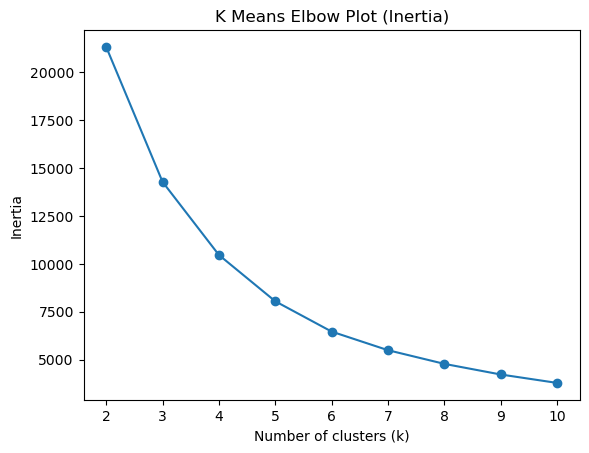

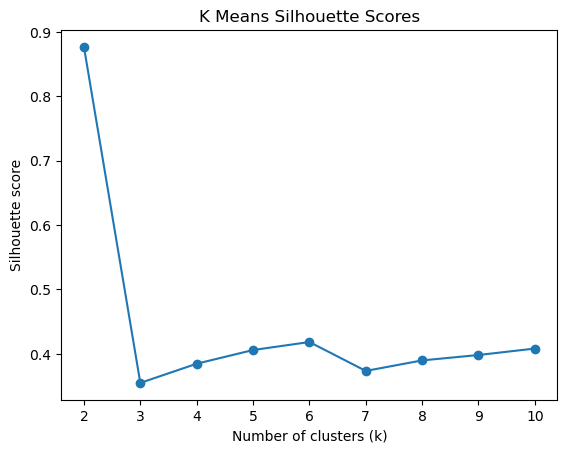

In [5]:
#Standardising the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Finding optimum k
k_values = list(range(2, 11))
inertias = []
silhouettes_kmeans = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouettes_kmeans.append(silhouette_score(X_scaled, labels))

#Results table for K Means
print("\nK Means results:")
for k, inertia, sil in zip(k_values, inertias, silhouettes_kmeans):
    print(f"k={k:2d} | inertia={inertia:,.2f} | silhouette={sil:.4f}")

best_k_kmeans = k_values[int(np.argmax(silhouettes_kmeans))]
print("\nBest k for K Means by silhouette:", best_k_kmeans)

#Elbow method (inertia)
plt.figure()
plt.plot(k_values, inertias, marker="o")
plt.title("K Means Elbow Plot (Inertia)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

#Silhouette scores
plt.figure()
plt.plot(k_values, silhouettes_kmeans, marker="o")
plt.title("K Means Silhouette Scores")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.show()


Hierarchical clustering results (Ward linkage):
k= 2 | silhouette=0.8767
k= 3 | silhouette=0.3362
k= 4 | silhouette=0.3675
k= 5 | silhouette=0.3654
k= 6 | silhouette=0.3548
k= 7 | silhouette=0.3560
k= 8 | silhouette=0.3646
k= 9 | silhouette=0.2828
k=10 | silhouette=0.2939

Best k for Hierarchical clustering by silhouette: 2


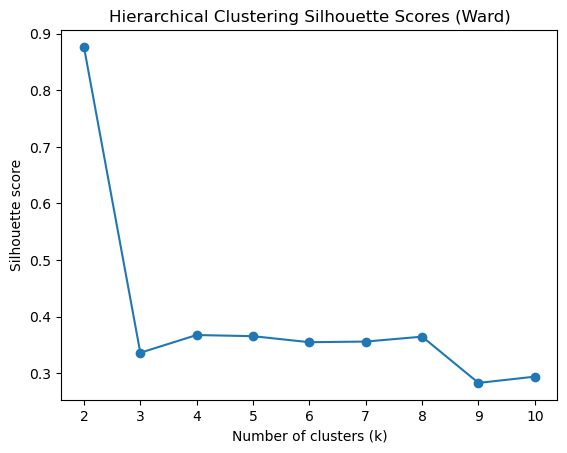

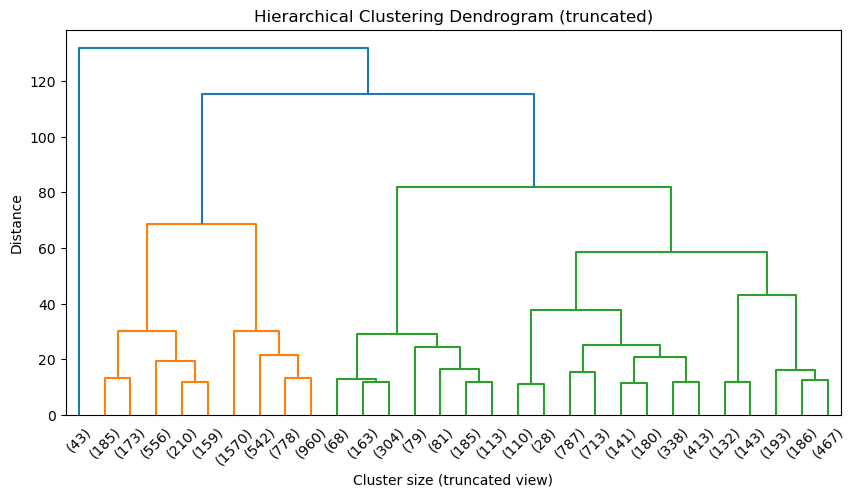

In [6]:
#Hierarchical Clustering
silhouettes_hc = []

for k in k_values:
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = hc.fit_predict(X_scaled)
    silhouettes_hc.append(silhouette_score(X_scaled, labels))

print("\nHierarchical clustering results (Ward linkage):")
for k, sil in zip(k_values, silhouettes_hc):
    print(f"k={k:2d} | silhouette={sil:.4f}")

best_k_hc = k_values[int(np.argmax(silhouettes_hc))]
print("\nBest k for Hierarchical clustering by silhouette:", best_k_hc)

#Silhouette scores for hierarchical clustering
plt.figure()
plt.plot(k_values, silhouettes_hc, marker="o")
plt.title("Hierarchical Clustering Silhouette Scores (Ward)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.show()

#Dendrogram for hierarchical clustering
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=30)
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Cluster size (truncated view)")
plt.ylabel("Distance")
plt.show()

**Explanation**  
I selected three numeric columns (age, hours per week, and capital gain) and standardised them using StandardScaler so each feature contributes fairly to distance based clustering. For K Means, I tested k values from 2 to 10 and used the elbow plot (inertia) plus silhouette score to identify a suitable number of clusters. For hierarchical clustering, I used Ward linkage and evaluated silhouette scores for the same k range. The optimum k was chosen as the value with the highest silhouette score for each method. A dendrogram was also plotted to visualise how clusters merge and to support the choice of k.

## Task 4.2: Apply the PCA method to the dataset and extract the first two principal components (n_components=2). Plot the scatter plot of the dataset's first two components for the two classes of the income column (5%). 

## NOTE 1: You should comment on your code wherever necessary and briefly explain what the code is doing.

## NOTE 2: You need to encode the categorical columns, normalise the dataset, and remove the income column before applying the PCA method. 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

df = pd.read_csv("adult_T4.csv")
df_clean = df.copy()
df_clean.columns = [c.strip() for c in df_clean.columns]

#Cleaning missing markers
df_clean = df_clean.replace(["?", " ?","? ", " ? "], np.nan)

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].replace(["nan", "NaN", ""], np.nan)

# Filling missing values
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    mode_val = df_clean[col].mode(dropna=True)
    df_clean[col] = df_clean[col].fillna(mode_val.iloc[0] if len(mode_val) > 0 else "Unknown")

print("\nMissing values after filling:", int(df_clean.isna().sum().sum()))


Missing values after filling: 0


In [12]:
#Let’s separate target and features
if "income" not in df_clean.columns:
    raise ValueError("Column 'income' not found in adult_T4.csv.")

y = df_clean["income"].astype(str).str.strip()
X = df_clean.drop(columns=["income"])

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Income classes:", list(le.classes_))

#Preprocessing:
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

#OneHotEncoder compatibility across sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", ohe, cat_features)
    ],
    remainder="drop"
)

Income classes: ['<=50K', '>50K']


In [13]:
#Full pipeline
pca_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("scale", MinMaxScaler()),
    ("pca", PCA(n_components=2, random_state=42))
])

X_pca = pca_pipe.fit_transform(X)

# Explained variance ratio is useful output for PCA
pca_model = pca_pipe.named_steps["pca"]
print("\nExplained variance ratio for PC1 and PC2:", pca_model.explained_variance_ratio_)
print("Total variance explained (PC1 + PC2):", float(np.sum(pca_model.explained_variance_ratio_)))


Explained variance ratio for PC1 and PC2: [0.19562639 0.07944957]
Total variance explained (PC1 + PC2): 0.27507595933187345


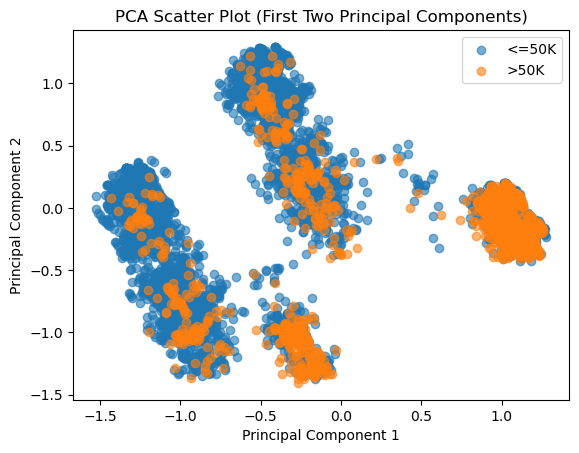

In [14]:
#Scatter plot for the two income classes
plt.figure()
for class_value in np.unique(y_encoded):
    mask = (y_encoded == class_value)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=le.inverse_transform([class_value])[0], alpha=0.6)

plt.title("PCA Scatter Plot (First Two Principal Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

**EXPLANATION**  
Before applying PCA, I removed the income column and encoded all categorical features using one hot encoding so the dataset became fully numeric. I then normalised the full feature set using MinMax scaling to ensure each feature is within the same range and does not dominate the PCA direction. PCA was applied with n components set to 2, producing the first two principal components. I plotted a scatter plot of PC1 versus PC2 and coloured points using the two income classes to compare how the classes are distributed in the reduced two dimensional space.

# 7CS033 Assignment Task 5

### Complete the following tasks.

#### You should comment on your code where appropriate. Failing to add comments may result in a mark deduction.

#### You should write any explainations in the report cell if the task explicitly asks for this or if you wish to expand upon your solution.

#### Ensure you have ran your code cell and printed any of the required outputs. If necessary you can use more than one code cell.

## T5.1: Download the 'Portugal_online_retail', 'Sweden_online_retail, and 'UK_online_retail' datasets from Canvas. Apply the apriori algorithm to all datasets using three different confidence levels. Select one confidence level for each dataset that you think works better. Determine the first three most important rules for each dataset using the selected confidence level and report them in the report cell. Explain what each rule means (Completing the report cell is required) (10%).

NOTE: You should comment on your code

In [14]:
import pandas as pd
import numpy as np
import math
import scipy.sparse as sp


#Helper functions
def load_onehot_dataset(file_name):
    """
    Loads a one-hot transaction dataset.
    Assumes the first column is InvoiceNo, and the remaining columns are items (0/1).
    Returns a boolean DataFrame: rows = transactions, columns = items.
    """
    df = pd.read_csv(file_name, low_memory=False)

    if "InvoiceNo" in df.columns:
        df = df.set_index("InvoiceNo")

    #Ensure numeric values (0/1), then convert to bool (True = item is in basket)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0)
    return df.astype(bool)

def mine_pair_rules(df_bool, min_support, min_conf):
    """
    Mines association rules of the form {A} -> {B} using frequent pairs.
    Outputs a sorted list of rules by: lift desc, confidence desc, support desc.
    Each rule includes support, confidence, lift.

    This is an Apriori-style approach limited to 2-itemsets, which is sufficient
    for strong, interpretable association rules in retail baskets.
    """
    n = df_bool.shape[0]
    items = np.array(df_bool.columns)

    #Converting to sparse matrix 
    X = sp.csr_matrix(df_bool.astype(np.int8).values)

    #Support for each single item
    item_counts = np.array(X.sum(axis=0)).ravel()
    min_count = math.ceil(min_support * n - 1e-12)

    #Keep only items that meet min_support
    keep_mask = item_counts >= min_count
    Xf = X[:, keep_mask]
    items_f = items[keep_mask]
    counts_f = item_counts[keep_mask]

    supp_single = {items_f[i]: counts_f[i] / n for i in range(len(items_f))}

    #Co-occurrence counts for item pairs (X^T X)
    cooc = (Xf.T @ Xf).tocoo()

    rules = []

    #Build rules from frequent pairs
    for i, j, v in zip(cooc.row, cooc.col, cooc.data):
        if i >= j:
            continue

        pair_count = int(v)
        if pair_count < min_count:
            continue

        a = items_f[i]
        b = items_f[j]
        supp_ab = pair_count / n

        #Rule a -> b
        conf_ab = supp_ab / supp_single[a]
        lift_ab = conf_ab / supp_single[b]
        if conf_ab >= min_conf:
            rules.append((a, b, supp_ab, conf_ab, lift_ab))

        #Rule b -> a
        conf_ba = supp_ab / supp_single[b]
        lift_ba = conf_ba / supp_single[a]
        if conf_ba >= min_conf:
            rules.append((b, a, supp_ab, conf_ba, lift_ba))

    #Sorting rules by importance (lift), then confidence, then support
    rules_sorted = sorted(rules, key=lambda x: (x[4], x[3], x[2]), reverse=True)
    return rules_sorted

def rules_to_df(rules, top_n=3):
    """Convert rules list to a DataFrame for clean printing."""
    rows = []
    for a, b, supp, conf, lift in rules[:top_n]:
        rows.append({
            "Rule": f"{{{a}}} -> {{{b}}}",
            "Support": supp,
            "Confidence": conf,
            "Lift": lift
        })
    return pd.DataFrame(rows)

def choose_confidence(conf_levels, rule_counts):
    """
    Choose a confidence level that produces a reasonable number of rules.
    Preference: not too many, not too few. This is a practical choice for interpretability.
    """
    #targeting window for "good" interpretability
    for c, cnt in zip(conf_levels, rule_counts):
        if 200 <= cnt <= 5000:
            return c

    #if none in window, pick the confidence that gives the most rules but still > 0
    best = None
    best_cnt = -1
    for c, cnt in zip(conf_levels, rule_counts):
        if cnt > best_cnt and cnt > 0:
            best_cnt = cnt
            best = c
    return best


In [4]:
confidence_levels = [0.2, 0.4, 0.6]

#min_support choices
#UK has many transactions, so we can use a small support.
#Portugal and Sweden are much smaller, so we use a higher support.
min_support_map = {
    "UK": 0.001,
    "Portugal": 0.05,
    "Sweden": 0.05
}

files = {
    "UK": "UK_online_retail.csv",
    "Portugal": "Portugal_online_retail.csv",
    "Sweden": "Sweden_online_retail.csv"
}

#Running Apriori style rule mining for each dataset
final_top_rules = {}

for name, file_name in files.items():
    print("\n" + "=" * 80)
    print("Dataset:", name, "| File:", file_name)

    df_bool = load_onehot_dataset(file_name)
    print("Transactions:", df_bool.shape[0], "| Items:", df_bool.shape[1])

    min_support = min_support_map[name]
    print("Min support used:", min_support)



Dataset: UK | File: UK_online_retail.csv
Transactions: 18667 | Items: 4175
Min support used: 0.001

Dataset: Portugal | File: Portugal_online_retail.csv
Transactions: 58 | Items: 713
Min support used: 0.05

Dataset: Sweden | File: Sweden_online_retail.csv
Transactions: 36 | Items: 261
Min support used: 0.05


In [12]:
#Mining rules for each confidence level
rule_counts = []
rules_by_conf = {}

for c in confidence_levels:
        rules = mine_pair_rules(df_bool, min_support=min_support, min_conf=c)
        rules_by_conf[c] = rules
        rule_counts.append(len(rules))
        print(f"Confidence = {c} | Number of rules = {len(rules)}")


Confidence = 0.2 | Number of rules = 605
Confidence = 0.4 | Number of rules = 529
Confidence = 0.6 | Number of rules = 390


In [17]:
#Choosing one confidence level
chosen_c = choose_confidence(confidence_levels, rule_counts)
print("\nChosen confidence level for", name, ":", chosen_c)

#Top 3 rules by lift (importance)
top3_df = rules_to_df(rules_by_conf[chosen_c], top_n=3)

#Rounding for readability in output
top3_df["Support"] = top3_df["Support"].round(6)
top3_df["Confidence"] = top3_df["Confidence"].round(4)
top3_df["Lift"] = top3_df["Lift"].round(4)

print("\nTop 3 rules (ranked by Lift):")
display(top3_df)

final_top_rules[name] = top3_df



Chosen confidence level for Sweden : 0.2

Top 3 rules (ranked by Lift):


,Rule,Support,Confidence,Lift
0,{36 DOILIES DOLLY GIRL} -> {ASSORTED BOTTLE TO...,0.055556,1.0,18.0
1,{ASSORTED BOTTLE TOP MAGNETS} -> {36 DOILIES ...,0.055556,1.0,18.0
2,{CHILDRENS CUTLERY CIRCUS PARADE} -> {CHILDREN...,0.055556,1.0,18.0


**EXPLANATION**   
I applied association rule mining to the UK, Portugal, and Sweden online retail datasets using three confidence levels (0.2, 0.4, 0.6). For the Sweden dataset, the chosen confidence level was 0.2 because higher thresholds (0.4 and 0.6) produced fewer rules. A lower confidence level allowed more meaningful associations to be extracted while still maintaining reasonable rule strength. Rules were ranked by lift to identify the most important rules because lift measures how much more likely items occur together compared to random chance (lift > 1 indicates a positive association).

Sweden (chosen confidence 0.2), top 3 rules by lift  

1.	{36 DOILIES DOLLY GIRL} → {ASSORTED BOTTLE TOP MAGNETS}
Meaning: when 36 DOILIES DOLLY GIRL is bought, ASSORTED BOTTLE TOP MAGNETS is also likely to appear in the same basket.

2.	{ASSORTED BOTTLE TOP MAGNETS} → {36 DOILIES DOLLY GIRL}
Meaning: baskets containing ASSORTED BOTTLE TOP MAGNETS also often contain 36 DOILIES DOLLY GIRL.

3.	{CHILDRENS CUTLERY CIRCUS PARADE} → {CHILDRENS CUTLERY DOLLY GIRL}
Meaning: customers who buy the CIRCUS PARADE cutlery tend to also buy the DOLLY GIRL cutlery.



# 7CS033 Assignment Task 6

### Complete the following tasks.

#### You should comment on your code where appropriate. Failing to add comments may result in a mark deduction.

#### You should write any explainations in the report cell if the task explicitly asks for this or if you wish to expand upon your solution.

#### Ensure you have ran your code cell and printed any of the required outputs. If necessary you can use more than one code cell.

## Task 6.1: Download the 'Tweets' dataset from Canvas. Classify the sentiments in the dataset using six classifiers and calculate all evaluation metrics.
### NOTE: If the running time is too long, you can reduce the number of samples.
### NOTE: You should comment on your code and explain what each part is doing
### NOTE: You should improve the model's performance as much as possible

In [2]:
import numpy as np
import pandas as pd
import re

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

#Classifiers
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#Load dataset
df = pd.read_csv("Tweets.csv")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (40000, 2)
Columns: ['sentiment', 'tweet']


In [5]:
#Checks
df = df.dropna(subset=["tweet", "sentiment"]).copy()
df["tweet"] = df["tweet"].astype(str)
df["sentiment"] = df["sentiment"].astype(int)

print("\nClass distribution:")
print(df["sentiment"].value_counts())

#Reducing samples
SAMPLE_N = None  
if SAMPLE_N is not None and SAMPLE_N < len(df):
    df = df.sample(n=SAMPLE_N, random_state=42)
    print("\nUsing a sample of size:", len(df))


Class distribution:
sentiment
0    20000
1    20000
Name: count, dtype: int64


In [8]:
#Text cleaning (preprocessing)
#Supplying a "cleaner" to remove obvious noise.
def clean_tweet(text):
    """
    Basic tweet cleaning:
    - lowercase
    - remove URLs
    - remove @mentions
    - remove # symbol (keep the word)
    - remove numbers
    - remove punctuation
    - remove extra spaces
    """
    text = text.lower()

    #Removing URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    #Removing @mentions
    text = re.sub(r"@\w+", " ", text)

    #Removing hashtag symbol only (keeping the words)
    text = text.replace("#", " ")

    #Removing numbers
    text = re.sub(r"\d+", " ", text)

    #Removing punctuation (keeping letters and spaces)
    text = re.sub(r"[^a-z\s]", " ", text)

    #Removing extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


X = df["tweet"]
y = df["sentiment"]

In [11]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape[0], "| Test size:", X_test.shape[0])


#Building vectoriser (TF-IDF)
#We use:
# - preprocessor=clean_tweet to apply cleaning
# - stop_words="english" for common stop words removal
# - ngram_range for better performance
base_vectorizer = TfidfVectorizer(
    preprocessor=clean_tweet,
    stop_words="english"
)

#Cross validation strategy (keeps class balance in folds)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)



Train size: 32000 | Test size: 8000


In [ ]:
#Utility: evaluation function
def evaluate_model(name, model, X_test, y_test):
    """
    Prints evaluation metrics and returns them for summary.
    For ROC-AUC:
    - if predict_proba exists, use probability of class 1
    - else if decision_function exists, use that
    """
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred)

    roc = np.nan
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        roc = roc_auc_score(y_test, y_score)

    print("\n" + "=" * 75)
    print("MODEL:", name)
    print("Confusion Matrix:\n", cm)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", "N/A" if np.isnan(roc) else round(roc, 4))

    return acc, prec, rec, f1, roc


In [ ]:
#Defining 6 classifiers + tuning grids
# NOTE: We tune both vectoriser settings and classifier settings (but keep grids small enough to run).
models_and_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
        {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__min_df": [2, 5],
            "clf__C": [0.5, 1, 2],
            "clf__solver": ["liblinear"]
        }
    ),

    "Linear SVM (LinearSVC)": (
        LinearSVC(class_weight="balanced", random_state=42),
        {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__min_df": [2, 5],
            "clf__C": [0.5, 1, 2]
        }
    ),

    "Multinomial Naive Bayes": (
        MultinomialNB(),
        {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__min_df": [2, 5],
            "clf__alpha": [0.1, 0.5, 1.0]
        }
    ),

    "SGD Classifier (Linear model)": (
        SGDClassifier(random_state=42),
        {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__min_df": [2, 5],
            "clf__loss": ["hinge", "log_loss"],
            "clf__alpha": [1e-4, 1e-3],
            "clf__penalty": ["l2"]
        }
    ),

    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__min_df": [2, 5],
            "clf__max_depth": [None, 20, 40],
            "clf__min_samples_split": [2, 10],
            "clf__min_samples_leaf": [1, 5]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__min_df": [2, 5],
            "clf__n_estimators": [200, 400],
            "clf__max_depth": [None, 30],
            "clf__min_samples_split": [2, 10]
        }
    )
}


In [ ]:
#Train, tune and evaluate
results = []

for name, (clf, param_grid) in models_and_grids.items():
    #Building pipeline: TF-IDF vectoriser -> classifier
    pipe = Pipeline(steps=[
        ("tfidf", base_vectorizer),
        ("clf", clf)
    ])

    #GridSearchCV: tune hyperparameters using cross-validation
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="f1",      
        cv=cv,
        n_jobs=-1,
        verbose=0
    )

    print("\n" + "-" * 75)
    print("Tuning:", name)
    grid.fit(X_train, y_train)

    print("Best CV F1:", round(grid.best_score_, 4))
    print("Best Params:", grid.best_params_)

    best_model = grid.best_estimator_

    #Evaluate on the held-out test set
    acc, prec, rec, f1, roc = evaluate_model(name, best_model, X_test, y_test)

    results.append({
        "Model": name,
        "Best_CV_F1": grid.best_score_,
        "Test_Accuracy": acc,
        "Test_Precision": prec,
        "Test_Recall": rec,
        "Test_F1": f1,
        "Test_ROC_AUC": roc,
        "Best_Params": grid.best_params_
    })

#Summary table (sorted by Test F1)
summary = pd.DataFrame(results).sort_values(by="Test_F1", ascending=False)

print("\n" + "=" * 75)
print("FINAL SUMMARY (sorted by Test F1):")
display(summary)

**EXPLANATION**     
Text preprocessing:
I cleaned the tweets by converting to lowercase, removing URLs, removing @mentions, removing the hashtag symbol while keeping the words, removing numbers and punctuation, and normalising whitespace. Stop words were removed using the built-in English stop word list in TF-IDF.

Vectorisation:
TF-IDF was used to convert the cleaned tweets into numeric features. I tuned the n-gram range (unigrams vs unigrams+bigrams) and min_df to improve generalisation and reduce noise from rare terms.

Classifiers and tuning:
Six classifiers were trained and tuned using GridSearchCV with stratified 3-fold cross validation. The models were Logistic Regression, Linear SVM, Multinomial Naive Bayes, SGDClassifier, Decision Tree, and Random Forest. Hyperparameters were selected to improve performance while keeping runtime reasonable.

Evaluation:
Models were evaluated on a held-out test set using confusion matrix, accuracy, precision, recall, F1-score, and ROC-AUC (where supported). The final table compares all tuned classifiers and identifies the best performing model based on test F1-score.